In [1]:
# %%
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import ttest_ind
import itertools

In [2]:
# Full model name → Short name mapping
model_name_map = {
    "BAAI__bge-base-en": "BAAI_bgeB",
    "BAAI__bge-base-en-v1.5": "BAAI_bgeB_v1.5",
    "BAAI__bge-large-en": "BAAI_bgeL",
    "BAAI__bge-large-en-v1.5": "BAAI_bgeL_v1.5",
    "BAAI__bge-small-en": "BAAI_bgeS",
    "BAAI__bge-small-en-v1.5": "BAAI_bgeS_v1.5",
    "BAAI__bge-m3": "BAAI_bgeM3",
    "DeepChem__ChemBERTa-77M-MTR": "DC_ChemBERTa",
    "facebook__contriever": "FB_contriever",
    "facebook__contriever-msmarco": "FB_contrieverMS",
    "google-bert__bert-base-uncased": "GGL_BERTbU",
    "intfloat__e5-small": "Intf_e5S",
    "intfloat__e5-small-v2": "Intf_e5S_v2",
    "intfloat__e5-base": "Intf_e5B",
    "intfloat__e5-base-v2": "Intf_e5B_v2",
    "intfloat__e5-large": "Intf_e5L",
    "intfloat__e5-large-v2": "Intf_e5L_v2",
    "intfloat__multilingual-e5-base": "Intf_mE5B",
    "intfloat__multilingual-e5-large": "Intf_mE5L",
    "intfloat__multilingual-e5-small": "Intf_mE5S",
    "jinaai__jina-embeddings-v2-base-en": "Jina_v2B",
    "jinaai__jina-embeddings-v2-small-en": "Jina_v2S",
    "microsoft__BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext": "MS_BiomedBERT_af",
    "microsoft__BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext": "MS_PubMedBERT_af",
    "microsoft__MiniLM-L12-H384-uncased": "MS_MiniLM384",
    "microsoft__mpnet-base": "MS_MPNetB",
    "m3rg-iitd__matscibert": "IITD_MatSci",
    "nomic-ai__nomic-bert-2048": "Nomic_BERT2048",
    "nomic-ai__nomic-embed-text-v1": "Nomic_text_v1",
    "nomic-ai__nomic-embed-text-v1.5": "Nomic_text_v1.5",
    "nomic-ai__nomic-embed-text-v2-moe":"Nomic_text_v2",
    "describeai__gemini": "Desc_Gemini",
    "hkunlp__instructor-xl": "HKU_InstructXL",
    "allenai__scibert_scivocab_uncased": "AI_SciBERT",
    "allenai__specter": "AI_Specter",
    "recobo__chemical-bert-uncased": "Rec_ChemBERT",
    "sentence-transformers__all-mpnet-base-v2": "Sent_allMPNetB_v2",
    "sentence-transformers__all-MiniLM-L6-v2": "Sent_MiniLM6_v2",
    "sentence-transformers__all-MiniLM-L12-v2": "Sent_MiniLM12_v2",
    "sentence-transformers__bert-base-nli-mean-tokens": "Sent_BERTnli",
    "sentence-transformers__gtr-t5-base": "Sent_gtrT5_B",
    "sentence-transformers__gtr-t5-large": "Sent_gtrT5_L",
    "sentence-transformers__gtr-t5-xl": "Sent_gtrT5_XL",
    "sentence-transformers__multi-qa-mpnet-base-dot-v1": "Sent_MQA_MPNetB",
    "sentence-transformers__paraphrase-multilingual-MiniLM-L12-v2": "Sent_paraMiniLM12",
    "multi-qa-mpnet-base-dot-v1": "MQA_MPNetB",
    "microsoft__BiomedNLP-PubMedBERT-base-uncased-abstract" : "MS_PubMedBERT_a",
    "microsoft__BiomedNLP-BiomedBERT-base-uncased-abstract" : "MS_BiomedBERT_a",
    "sentence-transformers__paraphrase-multilingual-mpnet-base-v2" : "Sent_paraMPNetB_v2",
}


In [3]:
# cell2b: Model classification (from your message)
model_classification = {
    "retrieval": [
        "BAAI__bge-base-en", "BAAI__bge-base-en-v1.5", "BAAI__bge-large-en", "BAAI__bge-large-en-v1.5",
        "BAAI__bge-small-en", "BAAI__bge-small-en-v1.5", "BAAI__bge-m3",
        "facebook__contriever", "facebook__contriever-msmarco",
        "intfloat__e5-small", "intfloat__e5-small-v2", "intfloat__e5-base", "intfloat__e5-base-v2",
        "intfloat__e5-large", "intfloat__e5-large-v2",
        "jinaai__jina-embeddings-v2-base-en", "jinaai__jina-embeddings-v2-small-en",
        "sentence-transformers__gtr-t5-base",  "sentence-transformers__multi-qa-mpnet-base-dot-v1",
        "sentence-transformers__gtr-t5-large", "sentence-transformers__gtr-t5-xl",
    ],
    "semantic_similarity": [
        "sentence-transformers__all-mpnet-base-v2", "sentence-transformers__all-MiniLM-L6-v2",
        "sentence-transformers__all-MiniLM-L12-v2", "sentence-transformers__bert-base-nli-mean-tokens"
    ],
    "multilingual": [
        "intfloat__multilingual-e5-small", "intfloat__multilingual-e5-base", "intfloat__multilingual-e5-large",
        "sentence-transformers__paraphrase-multilingual-mpnet-base-v2", "sentence-transformers__paraphrase-multilingual-MiniLM-L12-v2"
    ],
    "scientific": [
        "allenai__scibert_scivocab_uncased", "allenai__specter", "m3rg-iitd__matscibert"
    ],
    "biomedical_chemical": [
        "DeepChem__ChemBERTa-77M-MTR",
        "microsoft__BiomedNLP-BiomedBERT-base-uncased-abstract",
        "microsoft__BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext",
        "microsoft__BiomedNLP-PubMedBERT-base-uncased-abstract",
        "microsoft__BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext",
        "recobo__chemical-bert-uncased",
    ],
    "universal_encoders": [
        "nomic-ai__nomic-embed-text-v1", "nomic-ai__nomic-embed-text-v1.5", "nomic-ai__nomic-embed-text-v2-moe"
    ],
    "instruction_tuned": [
        "hkunlp__instructor-xl", "describeai__gemini"
    ],
    "foundation_nlp": [
        "google-bert__bert-base-uncased", "microsoft__MiniLM-L12-H384-uncased", "nomic-ai__nomic-bert-2048", "microsoft__mpnet-base", "multi-qa-mpnet-base-dot-v1"
    ],
}

# Build model -> category and short_model -> category
from collections import defaultdict

model_to_category = {
    full: cat
    for cat, models in model_classification.items()
    for full in models
}

# Reverse map to go from short -> full (based on your model_name_map)
short_to_full = {short: full for full, short in model_name_map.items()}

def get_category_for_short(short_name: str) -> str:
    full = short_to_full.get(short_name)
    return model_to_category.get(full, "other")

# Fixed category order (present ones first, keeps legends stable)
_category_order = [
    "retrieval", "semantic_similarity", "multilingual", "scientific",
    "biomedical_chemical", "universal_encoders", "instruction_tuned",
    "foundation_nlp", "other"
]


In [4]:
import os
import json
import numpy as np
import pandas as pd

def load_results_from_multiple_folders(base_dirs: list) -> pd.DataFrame:
    """
    Recursively load model results from multiple base directories.
    Detects result folders via presence of model_meta.json and parses
    all sibling task JSONs. Robust to layouts like:
      base/.../<model>_<hash>/<hash>/*.json
      base/.../<model>_main/<model>/<hash>/*.json
    """
    rows = []

    for base_dir in base_dirs:
        if not os.path.isdir(base_dir):
            print(f"⚠️ Warning: {base_dir} is not a directory. Skipping...")
            continue

        for root, dirs, files in os.walk(base_dir):
            if "model_meta.json" not in files:
                continue

            meta_path = os.path.join(root, "model_meta.json")
            try:
                with open(meta_path, "r") as f:
                    meta = json.load(f)
            except Exception as e:
                print(f"⚠️ Warning: Failed to read {meta_path}: {e}. Skipping this folder.")
                continue

            # Pull model name / revision from meta, fallback to path pieces
            model_full = (
                meta.get("model_name")
                or meta.get("model")
                or os.path.basename(os.path.dirname(root))  # parent folder name
            )
            revision = meta.get("model_revision") or os.path.basename(root)

            # Map to short name if available
            short_model = model_name_map.get(model_full, model_full)

            # Parse all sibling JSONs except meta
            for fname in files:
                if not fname.endswith(".json") or fname == "model_meta.json":
                    continue

                json_path = os.path.join(root, fname)
                try:
                    with open(json_path, "r") as f:
                        data = json.load(f)
                except Exception as e:
                    print(f"⚠️ Warning: Failed to read {json_path}: {e}. Skipping...")
                    continue

                scores = data.get("scores", {})
                tests = scores.get("test")
                if not isinstance(tests, list):
                    print(f"⚠️ Warning: Missing or invalid 'scores.test' in {json_path}. Skipping...")
                    continue

                for test_result in tests:
                    def g(key, default=np.nan):
                        return test_result.get(key, default)

                    row = {
                        "model": model_full,
                        "short_model": short_model,
                        "revision": revision,
                        "dataset": data.get("task_name", "Unknown"),
                        "task": test_result.get("task_name", os.path.splitext(fname)[0]),
                        "main_score": g("main_score"),

                        # NDCG
                        "ndcg_at_1": g("ndcg_at_1"),
                        "ndcg_at_3": g("ndcg_at_3"),
                        "ndcg_at_5": g("ndcg_at_5"),
                        "ndcg_at_10": g("ndcg_at_10"),
                        "ndcg_at_20": g("ndcg_at_20"),
                        "ndcg_at_100": g("ndcg_at_100"),
                        "ndcg_at_1000": g("ndcg_at_1000"),

                        # MAP
                        "map_at_1": g("map_at_1"),
                        "map_at_3": g("map_at_3"),
                        "map_at_5": g("map_at_5"),
                        "map_at_10": g("map_at_10"),
                        "map_at_20": g("map_at_20"),
                        "map_at_100": g("map_at_100"),
                        "map_at_1000": g("map_at_1000"),

                        # Recall
                        "recall_at_1": g("recall_at_1"),
                        "recall_at_3": g("recall_at_3"),
                        "recall_at_5": g("recall_at_5"),
                        "recall_at_10": g("recall_at_10"),
                        "recall_at_20": g("recall_at_20"),
                        "recall_at_100": g("recall_at_100"),
                        "recall_at_1000": g("recall_at_1000"),

                        # Precision
                        "precision_at_1": g("precision_at_1"),
                        "precision_at_3": g("precision_at_3"),
                        "precision_at_5": g("precision_at_5"),
                        "precision_at_10": g("precision_at_10"),
                        "precision_at_20": g("precision_at_20"),
                        "precision_at_100": g("precision_at_100"),
                        "precision_at_1000": g("precision_at_1000"),

                        # MRR
                        "mrr_at_1": g("mrr_at_1"),
                        "mrr_at_3": g("mrr_at_3"),
                        "mrr_at_5": g("mrr_at_5"),
                        "mrr_at_10": g("mrr_at_10"),
                        "mrr_at_20": g("mrr_at_20"),
                        "mrr_at_100": g("mrr_at_100"),
                        "mrr_at_1000": g("mrr_at_1000"),

                        "evaluation_time": data.get("evaluation_time", np.nan),
                    }
                    rows.append(row)

    return pd.DataFrame(rows)


In [5]:
base_dirs = ["../artifacts/embedding_models_screening/validation"]

df_combined = load_results_from_multiple_folders(base_dirs)
# Category per row (via short_model)
df_combined["category"] = df_combined["short_model"].map(get_category_for_short)

# Ensure short_model fallback to original name if not mapped
df_combined["short_model"] = df_combined["short_model"].fillna(df_combined["model"])

# Drop rows with missing main_score
df_combined = df_combined.dropna(subset=["main_score"])

# Sort by dataset, task, and main score
df_combined = df_combined.sort_values(
    by=["dataset", "task", "main_score"],
    ascending=[True, True, False]
).reset_index(drop=True)


In [6]:

summary_stats = df_combined.groupby(["dataset", "task"])[["main_score", "ndcg_at_10", "map_at_10", "recall_at_10", "precision_at_10", "mrr_at_10"]].describe()

# Pivot table for dataset-task comparison
df_pivot = df_combined.pivot_table(index="model", columns=["dataset", "task"], values="main_score")
df_pivot["Difference (Max-Min)"] = df_pivot.max(axis=1) - df_pivot.min(axis=1)

df_combined = df_combined[df_combined["task"].str.lower() != "coconutretrieval"]


In [7]:
import numpy as np
import pandas as pd

def f_beta_at_k(recall, ndcg, beta=1.0):
    """
    Compute F_{beta}@k from Recall@k and nDCG@k.

    Formula:
        F_beta@k = (1 + beta^2) * Recall@k * nDCG@k / (beta^2 * nDCG@k + Recall@k)

    Parameters
    ----------
    recall : float | array-like | pd.Series
        Recall@k values in [0, 1].
    ndcg : float | array-like | pd.Series
        nDCG@k values in [0, 1].
    beta : float, default=1.0
        Weighting parameter (beta > 0). beta>1 favors Recall; beta<1 favors nDCG.

    Returns
    -------
    float | np.ndarray | pd.Series
        F_beta@k with the same shape/type (Series if input is Series) as the inputs.

    Notes
    -----
    - If both denominator terms are 0 (recall==0 and ndcg==0), returns 0.
    - NaNs propagate (rows with any NaN yield NaN).
    """
    if beta <= 0:
        raise ValueError("beta must be > 0")

    # Preserve pandas Series index if provided
    is_series = isinstance(recall, pd.Series) or isinstance(ndcg, pd.Series)

    r = np.asarray(recall, dtype=float)
    d = np.asarray(ndcg, dtype=float)

    beta2 = beta * beta
    num = (1.0 + beta2) * r * d
    den = beta2 * d + r

    out = np.divide(num, den, out=np.zeros_like(num), where=den != 0)

    # Put back into a Series if either input was a Series
    if is_series:
        # choose index from recall if Series else from ndcg
        idx = recall.index if isinstance(recall, pd.Series) else ndcg.index
        out = pd.Series(out, index=idx, name=f"F_{beta:g}@k")

    return out



# Define the @k values available in the dataset
k_values = [1, 3, 5, 10, 20, 100, 1000]

# Choose beta (1.0 gives harmonic mean)
beta = 2.0

# Compute F_beta@k for each available k
for k in k_values:
    recall_col = f"recall_at_{k}"
    ndcg_col = f"ndcg_at_{k}"
    fbeta_col = f"F{beta:g}_at_{k}"

    if recall_col in df_combined.columns and ndcg_col in df_combined.columns:
        df_combined[fbeta_col] = f_beta_at_k(df_combined[recall_col], df_combined[ndcg_col], beta=beta)
    else:
        print(f"⚠️ Skipping @k={k} — missing one of [{recall_col}, {ndcg_col}]")

# Preview result
df_combined[[c for c in df_combined.columns if c.startswith('F')]].head()


,F2_at_1,F2_at_3,F2_at_5,F2_at_10,F2_at_20,F2_at_100,F2_at_1000
0,0.77778,0.827624,0.827624,0.921318,0.921318,0.965645,0.965645
1,0.77778,0.827624,0.827624,0.874718,0.874718,0.919778,0.963374
2,0.72222,0.772061,0.820181,0.913212,0.913212,0.957117,0.957117
3,0.72222,0.821594,0.821594,0.868102,0.868102,0.913148,0.956233
4,0.72222,0.772061,0.772061,0.866772,0.956881,0.956881,0.956881


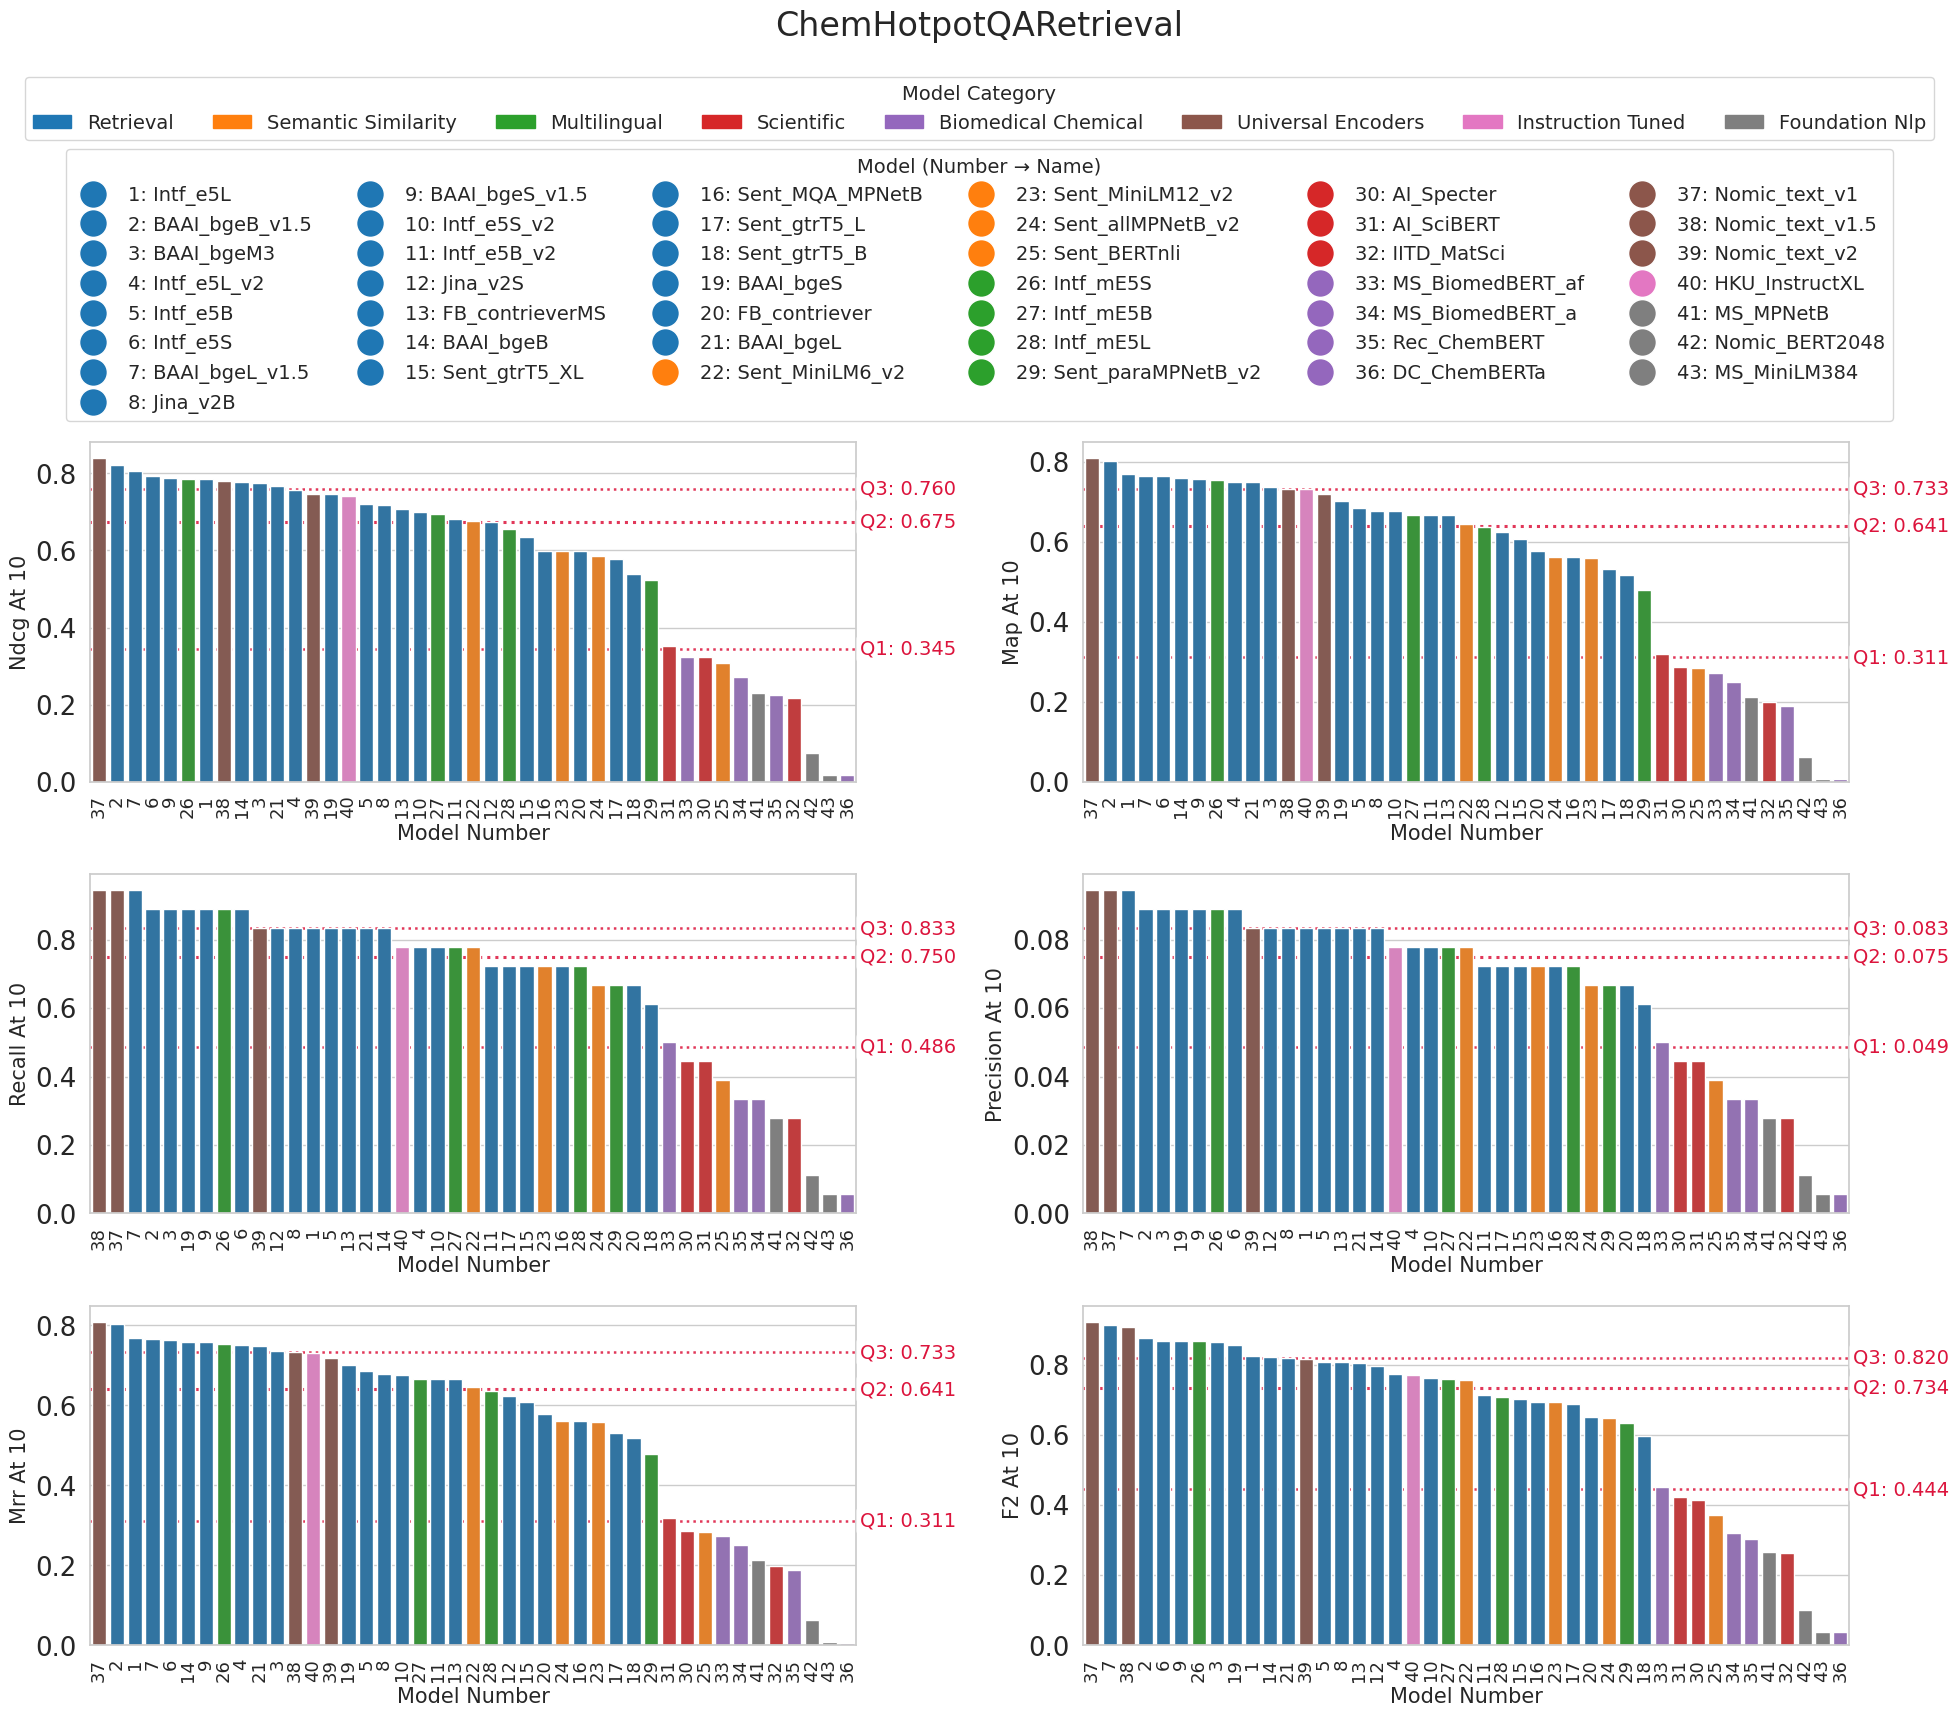

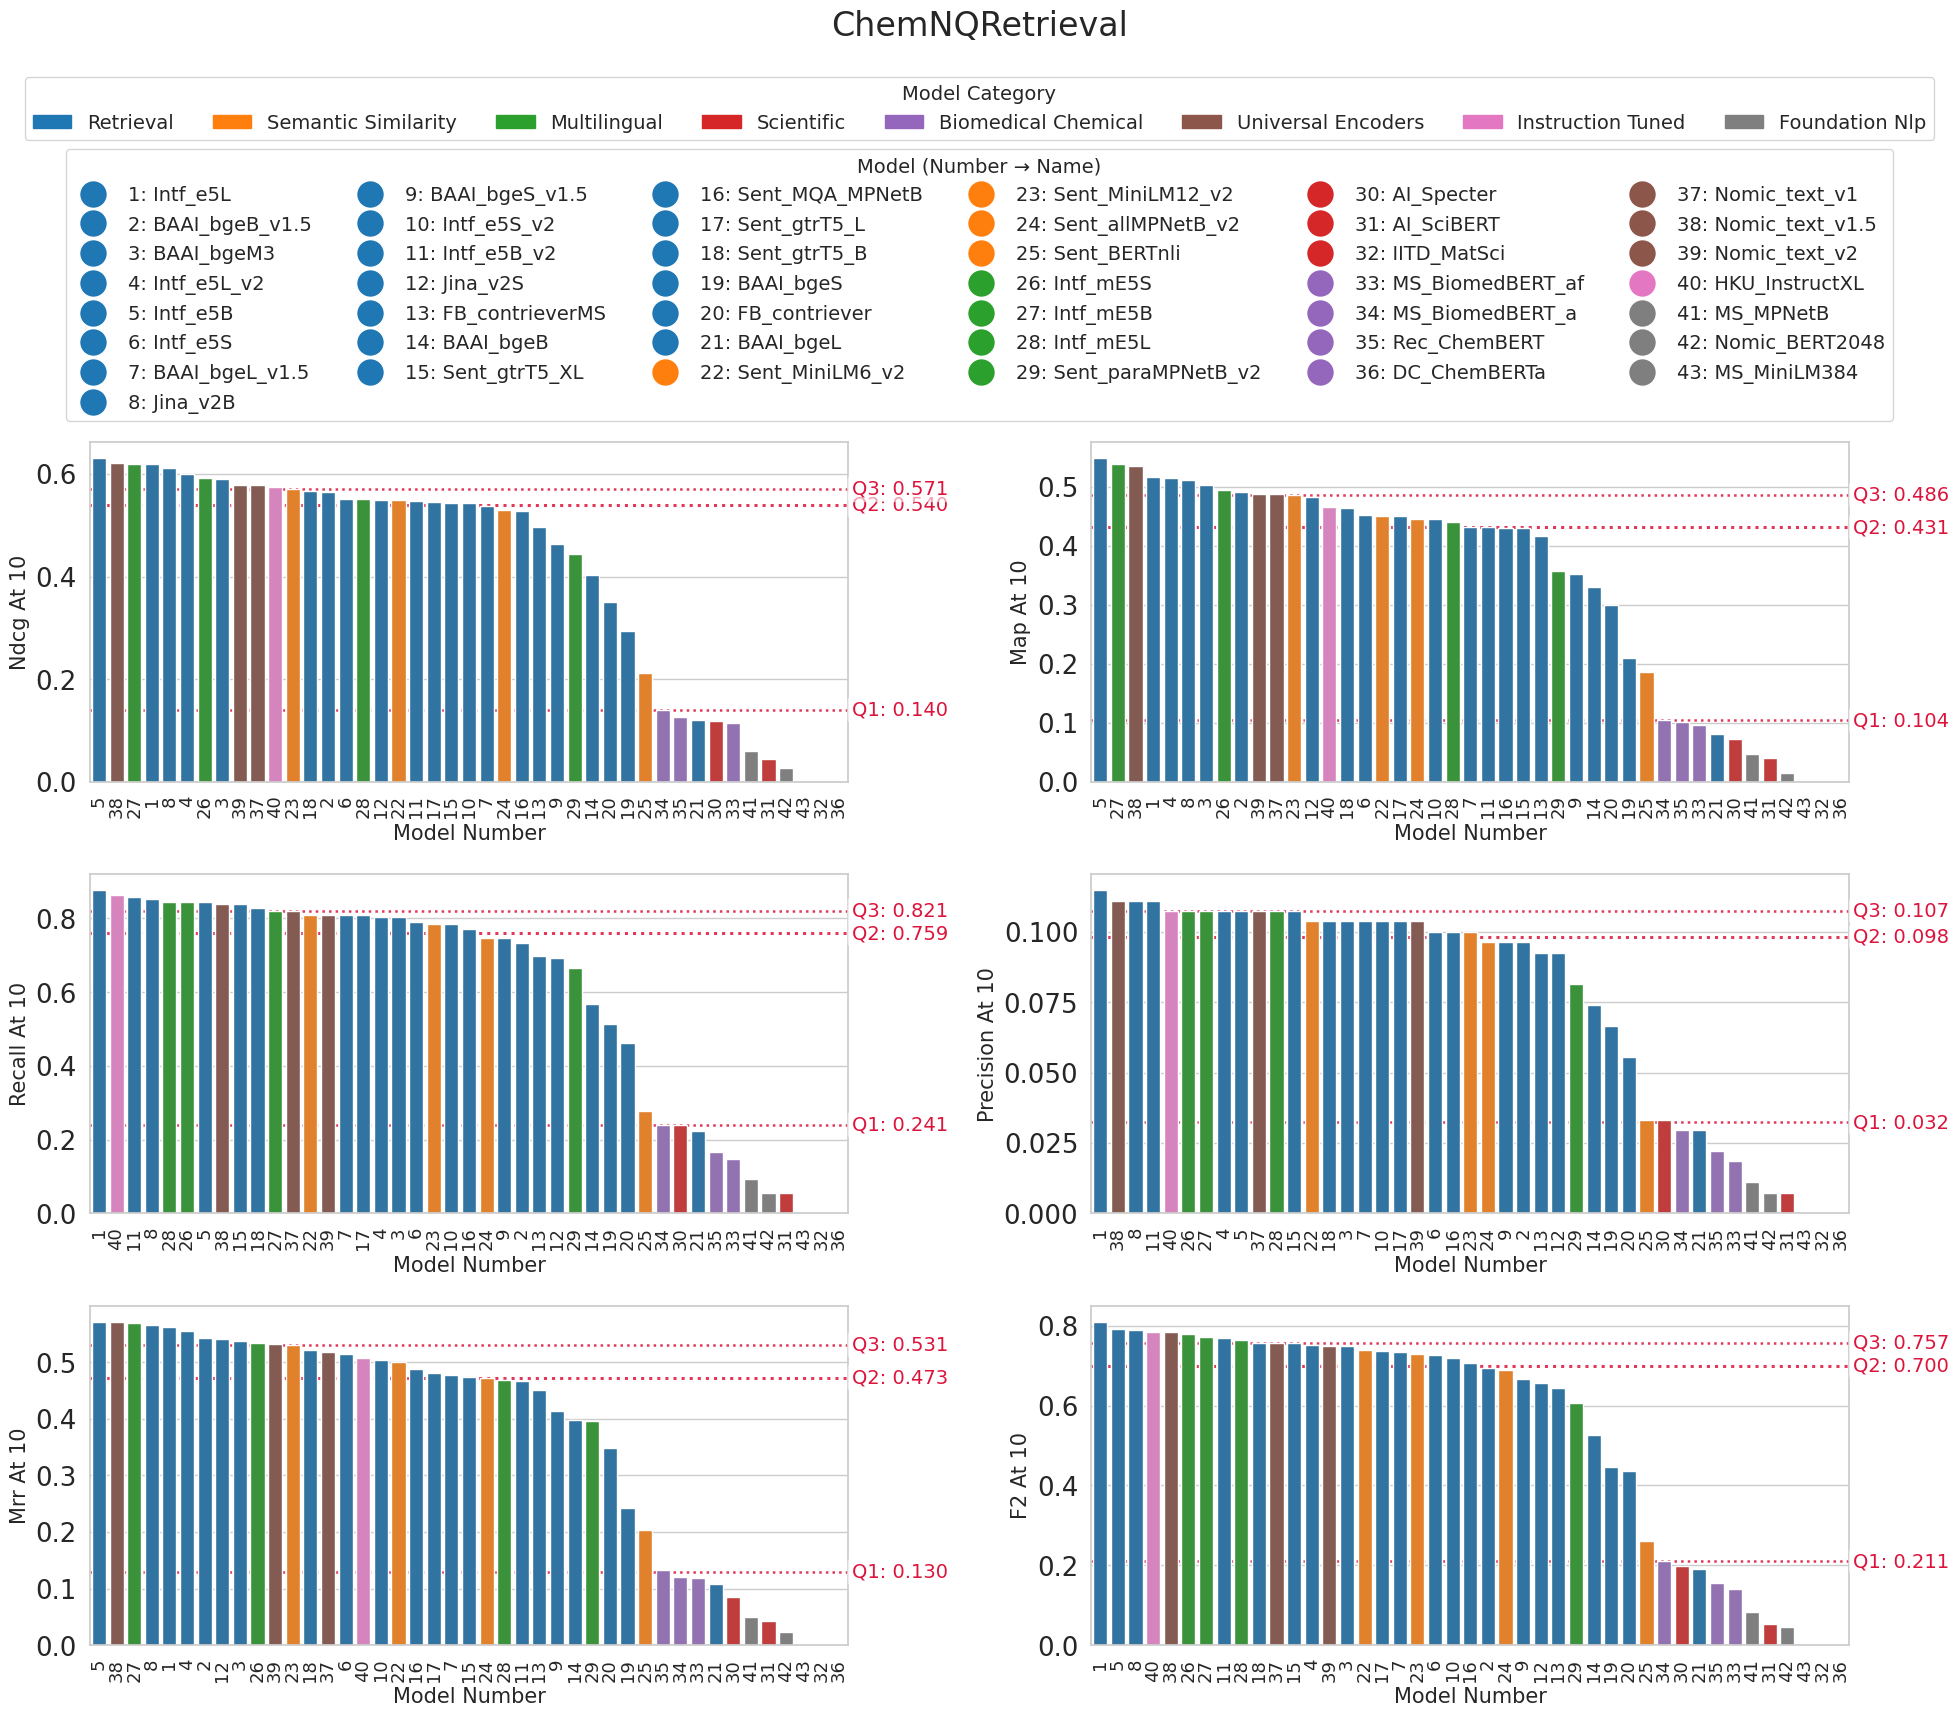

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.patches as mpatches

# -----------------------------
# Config & inputs (assumed available)
# -----------------------------
key_metrics = [
    "ndcg_at_10",
    "map_at_10",
    "recall_at_10",
    "precision_at_10",
    "mrr_at_10",
    "F2_at_10",
]
sns.set_theme(style="whitegrid", font_scale=1.7)

# Resolve task names robustly
all_tasks = df_combined["task"].unique().tolist()
def resolve_task_name(name):
    for t in all_tasks:
        if t.lower() == name.lower():
            return t
    for t in all_tasks:
        if name.lower() in t.lower():
            return t
    return name

task_hotpot = resolve_task_name("ChemHotPotQARetrieval")
task_chemnq = resolve_task_name("ChemNQRetrieval")

# -----------------------------
# Model selection & styling
# -----------------------------
mean_model_scores = (
    df_combined.groupby("short_model")["main_score"].mean()
    .sort_values(ascending=False)
)
top_short_models = mean_model_scores.head(50).index.tolist()

grouped_by_cat = defaultdict(list)
for sm in top_short_models:
    grouped_by_cat[get_category_for_short(sm)].append(sm)

present_cats = [c for c in _category_order if c in grouped_by_cat and len(grouped_by_cat[c]) > 0]
cat_rank = {cat: i for i, cat in enumerate(present_cats)}

base_cat_palette = sns.color_palette("tab10", n_colors=len(present_cats))
cat_to_color = dict(zip(present_cats, base_cat_palette))

model_colors = {
    sm: cat_to_color.get(get_category_for_short(sm), (0.6, 0.6, 0.6))
    for sm in top_short_models
}

base_rank = {sm: i for i, sm in enumerate(top_short_models)}
ordered_for_numbering = sorted(
    top_short_models,
    key=lambda sm: (cat_rank.get(get_category_for_short(sm), 10**9), base_rank[sm])
)
model_numbers = {sm: i + 1 for i, sm in enumerate(ordered_for_numbering)}  # 1..N

# Legends
cat_legend_handles = [
    mpatches.Patch(color=cat_to_color[cat], label=cat.replace("_", " ").title())
    for cat in present_cats
]
def legend_sort_key(sm):
    return (cat_rank.get(get_category_for_short(sm), 10**9), model_numbers[sm])
ordered_models_for_legend = sorted(top_short_models, key=legend_sort_key)
model_legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               label=f"{model_numbers[sm]}: {sm}",
               markerfacecolor=model_colors[sm], markersize=20)
    for sm in ordered_models_for_legend
]

# -----------------------------
# Plot helper: 2-column grid
# -----------------------------
def plot_task_figure(task_name, outfile):
    ncols = 2
    nrows = int(np.ceil(len(key_metrics) / ncols))
    ROW_HEIGHT = 4.8
    FIG_W = 20  # wider for two columns
    FIG_H = ROW_HEIGHT * nrows

    fig, axes = plt.subplots(
        nrows, ncols, figsize=(FIG_W, FIG_H), sharex=False, sharey=False
    )
    axes = np.array(axes).ravel()  # flatten for easy indexing
    fig.subplots_adjust(hspace=0.35, wspace=0.25, top=0.90, bottom=0.10)

    for i, metric in enumerate(key_metrics):
        ax = axes[i]
        task_data = df_combined[
            (df_combined["task"] == task_name) &
            (df_combined["short_model"].isin(top_short_models))
        ].copy()

        if task_name == "CoconutRetrieval":
            task_data[metric] *= 100

        model_order = (
            task_data.groupby("short_model")[metric]
            .mean().sort_values(ascending=False)
            .index.tolist()
        )

        sns.barplot(
            data=task_data,
            x="short_model", y=metric,
            hue="short_model",
            order=model_order, hue_order=model_order,
            ax=ax, palette=model_colors,
            errorbar=None, estimator=np.mean,
            legend=False, dodge=False
        )

        numbers_in_order = [str(model_numbers[m]) for m in model_order]
        ax.set_xticks(np.arange(len(model_order)))
        ax.set_xticklabels(numbers_in_order, rotation=90, fontsize=13)
        ax.set_xlabel("Model Number", fontsize=15)
        ax.set_ylabel(metric.replace("_", " ").title(), fontsize=15)

        vals = task_data[metric].dropna().to_numpy()
        if vals.size:
            q1, q2, q3 = np.percentile(vals, [25, 50, 75])
            for y, label, ls, lw in [(q1, "Q1", ":", 1.8),
                                     (q2, "Q2", ":", 2.2),
                                     (q3, "Q3", ":", 1.8)]:
                ax.axhline(y, color="crimson", linestyle=ls, linewidth=lw, alpha=0.85, zorder=0)
                ax.annotate(
                    f"{label}: {y:.3f}",
                    xy=(1.005, y),
                    xycoords=("axes fraction", "data"),
                    va="center", ha="left",
                    fontsize=14, color="crimson",
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6),
                    clip_on=False
                )

    # Hide any unused axes (in case metrics count isn't multiple of 2)
    for j in range(len(key_metrics), nrows * ncols):
        axes[j].set_visible(False)

    fig.suptitle(task_name, fontsize=24, y=1.20)

    plt.rcParams['legend.fontsize'] = 14
    plt.rcParams['legend.title_fontsize'] = 14
    fig.legend(
        handles=cat_legend_handles, title="Model Category",
        loc='upper center', bbox_to_anchor=(0.5, 1.16),
        ncol=min(len(present_cats), 8)
    )
    fig.legend(
        handles=model_legend_handles, title="Model (Number → Name)",
        loc='upper center', bbox_to_anchor=(0.5, 1.11),
        ncol=6
    )

    plt.tight_layout(rect=[0, 0, 1, 0.965])
    plt.savefig(outfile, dpi=300, bbox_inches='tight')
    plt.show()


# -----------------------------
# Text summaries for each subplot (per task & metric)
# -----------------------------
from pathlib import Path

def generate_text_summary(task_name, outfile_txt, top_k=5):
    lines = []
    lines.append(f"# Text Summary: {task_name}\n")

    # Header: category legend and model numbering
    lines.append("## Model Categories")
    for cat in present_cats:
        lines.append(f"- {cat.replace('_',' ').title()}")
    lines.append("")

    lines.append("## Model Number → Name")
    # Use same legend ordering for readability
    for sm in ordered_models_for_legend:
        lines.append(f"- {model_numbers[sm]}: {sm}")
    lines.append("")

    for metric in key_metrics:
        task_data = df_combined[
            (df_combined["task"] == task_name) &
            (df_combined["short_model"].isin(top_short_models))
        ].copy()

        # Match your figure scaling for CoconutRetrieval
        if task_name == "CoconutRetrieval":
            task_data[metric] *= 100

        # If no data for this metric/task, skip
        if task_data.empty or task_data[metric].dropna().empty:
            lines.append(f"## {metric.replace('_', ' ').title()}")
            lines.append("_No data available for this metric/task._\n")
            continue

        # Model ranking = same as the bars
        model_order = (
            task_data.groupby("short_model")[metric]
            .mean().sort_values(ascending=False)
            .index.tolist()
        )

        # Quartiles (as used for the crimson reference lines)
        vals = task_data[metric].dropna().to_numpy()
        q1, q2, q3 = np.percentile(vals, [25, 50, 75])

        # Top-K models with their mean scores
        lines.append(f"## {metric.replace('_', ' ').title()}")
        lines.append(f"**Top {min(top_k, len(model_order))} Models**")
        for sm in model_order[:top_k]:
            mean_val = task_data[task_data["short_model"] == sm][metric].mean()
            num = model_numbers[sm]
            cat = get_category_for_short(sm)
            lines.append(f"- #{num} **{sm}** (Category: {cat}) — mean {metric}: {mean_val:.4f}")
        lines.append("")
        lines.append(f"**Quartiles for {metric}:** Q1 = {q1:.3f}, Median (Q2) = {q2:.3f}, Q3 = {q3:.3f}\n")

    text = "\n".join(lines)

    # Write text and a Markdown twin
    outfile_txt = Path(outfile_txt)
    outfile_md = outfile_txt.with_suffix(".md")
    outfile_txt.parent.mkdir(parents=True, exist_ok=True)
    with open(outfile_txt, "w", encoding="utf-8") as f:
        f.write(text)
    with open(outfile_md, "w", encoding="utf-8") as f:
        f.write(text)

    # Also print to console (optional)
    # print(text)
# -----------------------------
# Generate the two figures
# -----------------------------
plot_task_figure(task_hotpot, "../artifacts/figs/ChemHotPotQARetrieval_Top_Models.jpg")
plot_task_figure(task_chemnq, "../artifacts/figs/ChemNQRetrieval_Top_Models.jpg")


# -----------------------------
# Generate text reports for the two tasks
# -----------------------------
generate_text_summary(task_hotpot, "../artifacts/figs/ChemHotPotQARetrieval_Top_Models.md")
generate_text_summary(task_chemnq, "../artifacts/figs/ChemNQRetrieval_Top_Models.md")



/tmp/ipykernel_1898837/1187040220.py:190: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('1').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax_mean.scatter(row["DR1_plot"], row["DR2_plot"],
/tmp/ipykernel_1898837/1187040220.py:190: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('2').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax_mean.scatter(row["DR1_plot"], row["DR2_plot"],
/tmp/ipykernel_1898837/1187040220.py:190: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('3').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax_mean.scatter(row["DR1_plot"], row["DR2_plot"],
/tmp/ipykernel_1898837/1187040220.py:190: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('4').  Matplotli

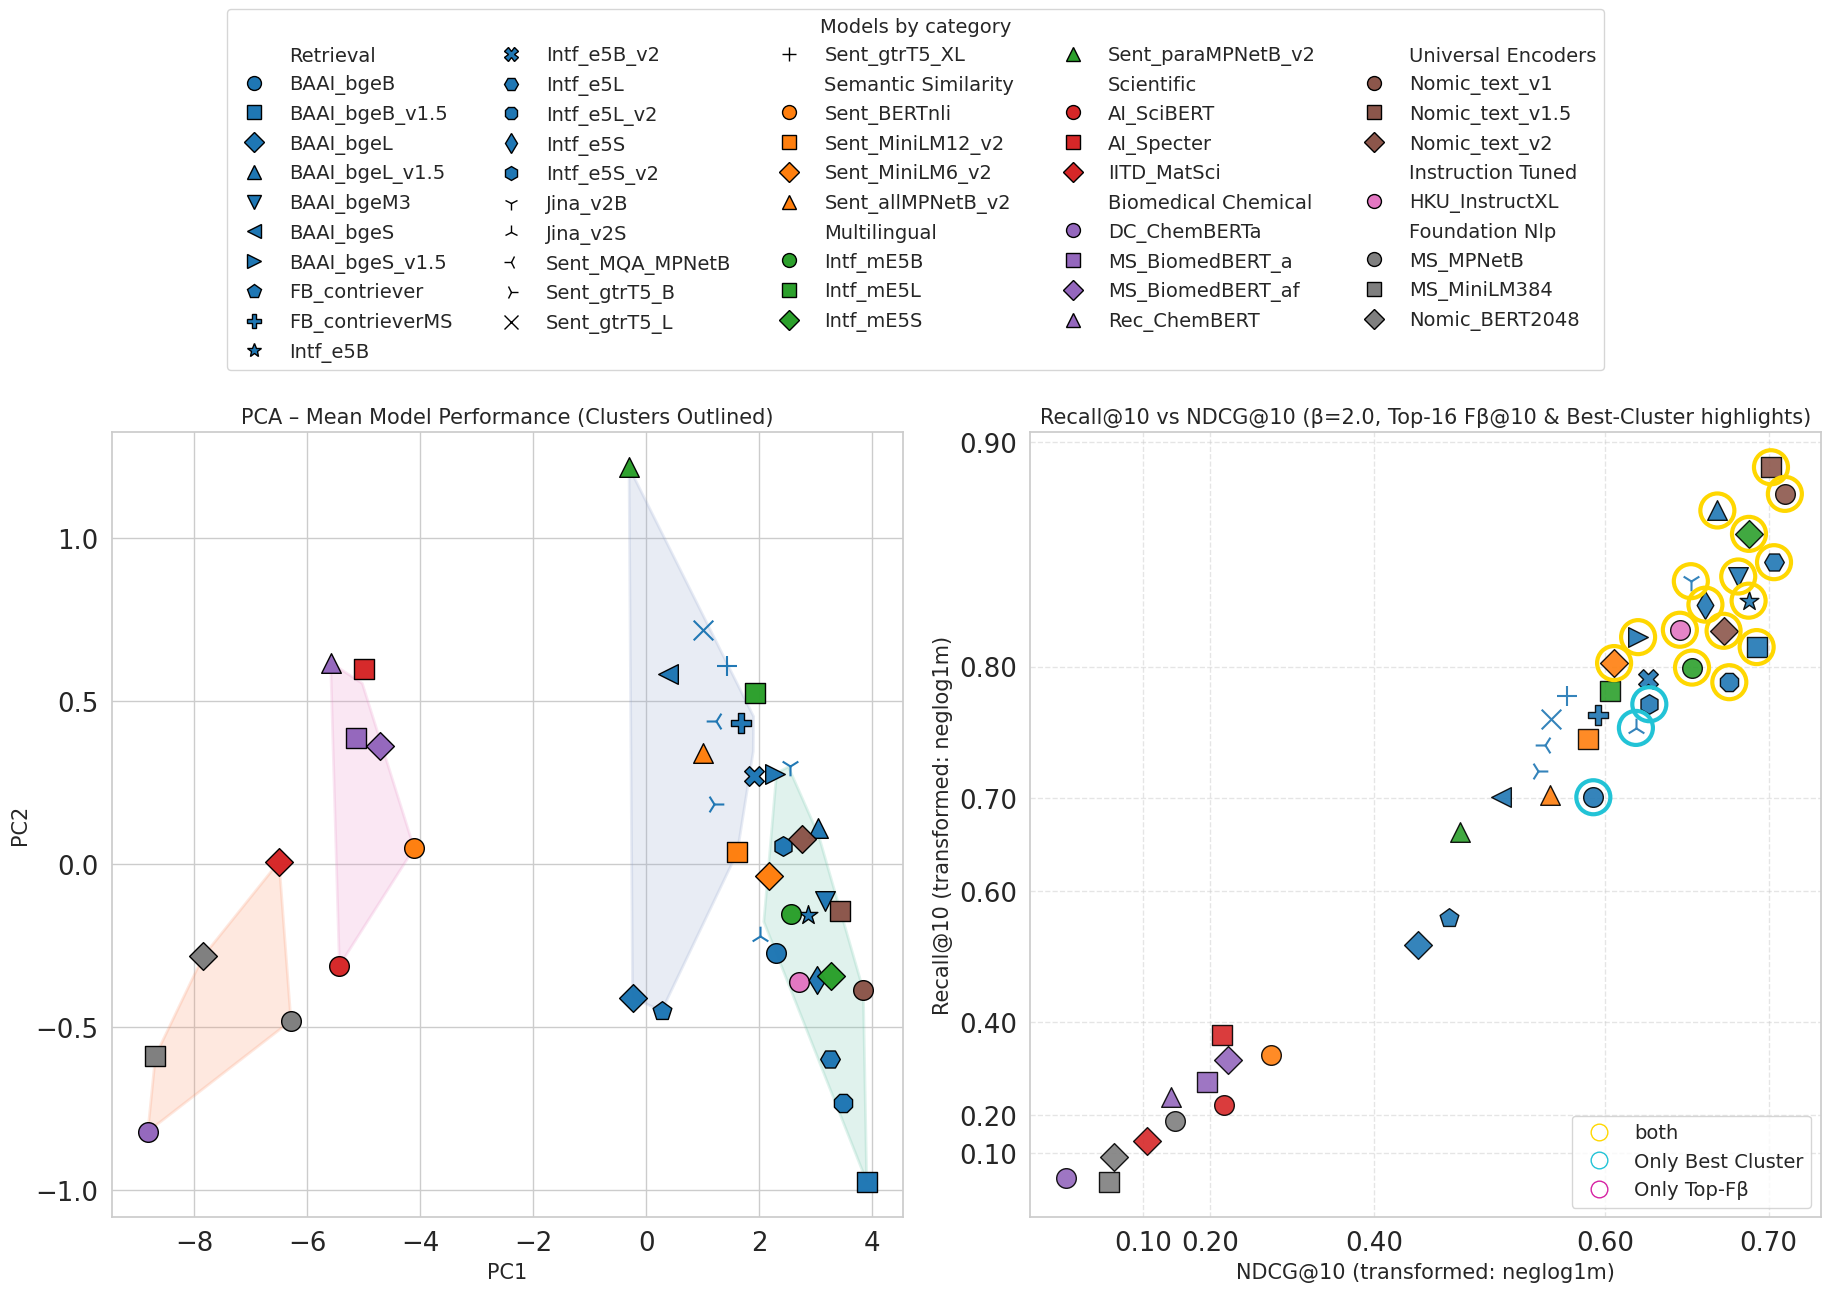

📄 Report saved to: ../artifacts/figs/PCA_DR_report.md


In [11]:
def plot_dim_reduction_per_dataset(
    df: pd.DataFrame,
    metric_cols: list,
    method: str = "pca",
    k_clusters: int = 4,
    fig_path: str = "../artifacts/figs/PCA_of_Model_Performance_by_Dataset_Mean_Cluster_Borders.jpg",
    beta: float = 2.0,
    top_n_fbeta: int = 10,
    colors: dict | None = None,
    recall_transform: str | None = "neglog1m",   # "neglog1m", "logit", or None
    ndcg_transform: str | None = "neglog1m",     # "neglog1m", "logit", or None
    report_path: str = "../artifacts/figs/DR_report.md",  # <-- NEW
):
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from scipy.spatial import ConvexHull, QhullError, cKDTree
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from matplotlib.lines import Line2D
    import matplotlib.patches as mpatches
    import matplotlib.colors as mcolors
    import os
    import io
    import textwrap
    import pandas as pd  # ensure available inside

    colors = colors or {
        "intersection": "gold",
        "only_cluster": "#22c3d6",
        "only_topF": "#d622a3",
    }

    # ---------- transforms for bounded metrics in [0,1] ----------
    def _transform_prob(p, kind="neglog1m", eps=1e-9):
        if kind is None:
            return np.asarray(p, dtype=float)
        p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
        if kind == "logit":
            return np.log(p / (1 - p))
        elif kind == "neglog1m":
            return -np.log(1 - p)
        else:
            return p

    def _inverse_transform_prob(x, kind="neglog1m"):
        if kind is None:
            return np.asarray(x, dtype=float)
        x = np.asarray(x, dtype=float)
        if kind == "logit":
            return 1 / (1 + np.exp(-x))
        elif kind == "neglog1m":
            return 1 - np.exp(-x)
        else:
            return x

    # ---------- collision-avoidance (repulsion) for overlapping markers ----------
    def _repel_points(x, y, min_dist_frac=0.02, iters=300, lr=0.12, seed=42):
        x = np.asarray(x, float); y = np.asarray(y, float)
        pos = np.stack([x, y], axis=1).copy()
        rng = np.random.default_rng(seed)
        pos += (rng.random(pos.shape) - 0.5) * 1e-8
        rx = np.ptp(x); ry = np.ptp(y)
        scale = max(rx, ry, 1.0)
        min_dist = min_dist_frac * scale
        for _ in range(iters):
            tree = cKDTree(pos)
            pairs = tree.query_pairs(min_dist)
            if not pairs: break
            disp = np.zeros_like(pos)
            for i, j in pairs:
                dvec = pos[i] - pos[j]
                d = np.linalg.norm(dvec) + 1e-12
                push = (min_dist - d) / d * dvec
                disp[i] += push; disp[j] -= push
            pos += lr * disp
        return pos[:, 0], pos[:, 1]

    def compute_dr(X, method_):
        Xs = StandardScaler().fit_transform(X)
        if method_.lower() == "pca":
            dr = PCA(n_components=2, random_state=42)
            X_dr = dr.fit_transform(Xs)
            return X_dr, "PC1", "PC2", "PCA", dr.explained_variance_ratio_
        else:
            dr = TSNE(n_components=2, perplexity=10, random_state=42)
            X_dr = dr.fit_transform(Xs)
            return X_dr, "t-SNE1", "t-SNE2", "t-SNE", None

    # --- Clean + prep
    metric_cols = [c for c in metric_cols if c in df.columns]
    df_clean = df.dropna(subset=metric_cols).copy()
    if df_clean.empty:
        print("⚠️ No data after dropping NaNs.")
        return

    if "short_model" not in df_clean.columns:
        df_clean["short_model"] = df_clean.get("model", "model")
    df_clean["short_model"] = df_clean["short_model"].fillna(df_clean.get("model"))

    # Add category from short_model
    df_clean["category"] = df_clean["short_model"].map(get_category_for_short).fillna("other")

    # Global DR (info only)
    X_all = df_clean[metric_cols].values
    X_dr_all, x_label, y_label, title_prefix, evr = compute_dr(X_all, method)

    # --------- Mean per model ---------
    df_mean = df_clean.groupby("short_model", as_index=False)[metric_cols].mean()
    df_mean = df_mean.merge(
        df_clean[["short_model", "category"]].drop_duplicates(),
        on="short_model", how="left"
    )
    df_mean["category"] = df_mean["category"].fillna("other")

    X_mean = df_mean[metric_cols].values
    X_dr_mean, _, _, _, _ = compute_dr(X_mean, method)
    df_mean["DR1"], df_mean["DR2"] = X_dr_mean[:, 0], X_dr_mean[:, 1]

    # KMeans clusters on DR space
    try:
        kmeans_mean = KMeans(n_clusters=k_clusters, random_state=42, n_init="auto")
    except TypeError:
        kmeans_mean = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    df_mean["cluster"] = kmeans_mean.fit_predict(df_mean[["DR1", "DR2"]].values)

    # ---------- Styles ----------
    unique_models = sorted(df_mean["short_model"].unique())
    model_markers = ['o','s','D','^','v','<','>','p','P','*','X','H','8','d','h','1','2','3','4','x','+','|','_']

    present_cats = [c for c in _category_order if c in df_mean["category"].unique()]
    for c in sorted(df_mean["category"].unique()):
        if c not in present_cats:
            present_cats.append(c)

    cat_palette = sns.color_palette("tab10", n_colors=len(present_cats))
    cat_to_color = dict(zip(present_cats, cat_palette))

    model_to_marker = {}
    for cat in present_cats:
        cat_models = sorted(df_mean.loc[df_mean["category"] == cat, "short_model"].unique())
        for i, m in enumerate(cat_models):
            model_to_marker[m] = model_markers[i % len(model_markers)]

    model_to_cat = df_mean.set_index("short_model")["category"].to_dict()
    model_style_map = {
        m: {
            'color': cat_to_color.get(model_to_cat.get(m, "other"), (0.6, 0.6, 0.6)),
            'marker': model_to_marker.get(m, 'o'),
        }
        for m in unique_models
    }
    cluster_colors = sns.color_palette("Set2", k_clusters)

    # ---------- Figure (1 row, 2 columns) ----------
    fig, axes = plt.subplots(1, 2, figsize=(19.5, 13), constrained_layout=False)
    ax_mean, ax_right = axes

    # ===== Left: DR with cluster hulls =====
    hull_info = {}  # NEW: keep hull area/points per cluster
    for c in sorted(df_mean["cluster"].unique()):
        pts = df_mean[df_mean["cluster"] == c][["DR1", "DR2"]].values
        if len(pts) >= 3:
            try:
                hull = ConvexHull(pts)
                poly = pts[hull.vertices]
                ax_mean.fill(*zip(*poly), alpha=0.20,
                             color=cluster_colors[c % len(cluster_colors)],
                             edgecolor=cluster_colors[c % len(cluster_colors)],
                             linewidth=2)
                hull_info[c] = {
                    "area": float(hull.volume),  # in 2D, volume is area
                    "n_hull_vertices": int(len(hull.vertices)),
                }
            except QhullError:
                hull_info[c] = {"area": None, "n_hull_vertices": 0}
        else:
            hull_info[c] = {"area": None, "n_hull_vertices": 0}

    dr1_rep, dr2_rep = _repel_points(
        df_mean["DR1"].values, df_mean["DR2"].values,
        min_dist_frac=0.02, iters=300, lr=0.12, seed=42
    )
    df_mean["DR1_plot"], df_mean["DR2_plot"] = dr1_rep, dr2_rep

    for _, row in df_mean.iterrows():
        style = model_style_map[row["short_model"]]
        ax_mean.scatter(row["DR1_plot"], row["DR2_plot"],
                        color=style["color"], marker=style["marker"],
                        edgecolor="black", s=200, alpha=0.99)
    ax_mean.set_title(f"{title_prefix} – Mean Model Performance (Clusters Outlined)", fontsize=15)
    ax_mean.set_xlabel(x_label, fontsize=15)
    ax_mean.set_ylabel(y_label, fontsize=15)

    # ===== Compute F_beta@10 & sets =====
    has_rn = {"recall_at_10", "ndcg_at_10"}.issubset(df.columns) or \
             {"recall_at_10", "ndcg_at_10"}.issubset(df_mean.columns)

    intersect_models = set(); only_cluster_models = set(); only_topF_models = set()
    best_cluster = None
    if has_rn:
        if "recall_at_10" not in df_mean.columns and "recall_at_10" in df_clean.columns:
            df_mean = df_mean.merge(
                df_clean.groupby("short_model")["recall_at_10"].mean().reset_index(),
                on="short_model", how="left"
            )
        if "ndcg_at_10" not in df_mean.columns and "ndcg_at_10" in df_clean.columns:
            df_mean = df_mean.merge(
                df_clean.groupby("short_model")["ndcg_at_10"].mean().reset_index(),
                on="short_model", how="left"
            )

        eps = 1e-12
        R = df_mean["recall_at_10"].astype(float)
        N = df_mean["ndcg_at_10"].astype(float)
        df_mean["Fbeta_at_10"] = ((1 + beta**2) * R * N) / (beta**2 * N + R + eps)

        df_mean["mean_metric"] = df_mean[metric_cols].mean(axis=1)
        best_cluster = df_mean.groupby("cluster")["mean_metric"].mean().idxmax()

        best_cluster_models = set(df_mean.loc[df_mean["cluster"] == best_cluster, "short_model"])
        topF_models = set(df_mean.nlargest(top_n_fbeta, "Fbeta_at_10")["short_model"])

        intersect_models = best_cluster_models & topF_models
        only_cluster_models = best_cluster_models - topF_models
        only_topF_models = topF_models - best_cluster_models

    # ===== Right: Recall vs NDCG =====
    if {"recall_at_10", "ndcg_at_10"}.issubset(df_mean.columns):

        df_mean["ndcg_t"]   = _transform_prob(df_mean["ndcg_at_10"],   kind=ndcg_transform)
        df_mean["recall_t"] = _transform_prob(df_mean["recall_at_10"], kind=recall_transform)

        x_rep, y_rep = _repel_points(
            df_mean["ndcg_t"].values, df_mean["recall_t"].values,
            min_dist_frac=0.035, iters=350, lr=0.12, seed=42
        )
        df_mean["ndcg_t_plot"], df_mean["recall_t_plot"] = x_rep, y_rep

        for _, row in df_mean.iterrows():
            style = model_style_map[row["short_model"]]
            ax_right.scatter(
                row["ndcg_t_plot"], row["recall_t_plot"],
                color=style["color"], marker=style["marker"],
                edgecolor="black", s=200, alpha=0.9
            )

        def ring_for(models, edgecolor):
            sub = df_mean[df_mean["short_model"].isin(models)]
            ax_right.scatter(
                sub["ndcg_t_plot"], sub["recall_t_plot"],
                s=600, facecolors='none', edgecolors=edgecolor,
                linewidth=3, zorder=3
            )

        ring_for(intersect_models, colors["intersection"])
        ring_for(only_cluster_models, colors["only_cluster"])
        ring_for(only_topF_models, colors["only_topF"])

        # ticks
        def _pretty_ticks_from_data(series, default_n=6):
            smin, smax = float(series.min()), float(series.max())
            base = np.array([0.1, 0.2, 0.4, 0.6, 0.7, 0.8, 0.9, 0.95, 0.98, 0.99])
            keep = base[(base >= max(0.0, np.floor(smin*10)/10)) &
                        (base <= min(0.999, np.ceil(smax*100)/100))]
            if keep.size == 0:
                keep = np.linspace(max(0.0, smin), min(0.999, smax), default_n)
            return keep

        pretty_ndcg = _pretty_ticks_from_data(df_mean["ndcg_at_10"])
        ax_right.set_xticks(_transform_prob(pretty_ndcg, kind=ndcg_transform))
        ax_right.set_xticklabels([f"{v:.2f}" for v in pretty_ndcg])
        pretty_recall = _pretty_ticks_from_data(df_mean["recall_at_10"])
        ax_right.set_yticks(_transform_prob(pretty_recall, kind=recall_transform))
        ax_right.set_yticklabels([f"{v:.2f}" for v in pretty_recall])

        x_suffix = "" if ndcg_transform is None else f" (transformed: {ndcg_transform})"
        y_suffix = "" if recall_transform is None else f" (transformed: {recall_transform})"
        ax_right.set_xlabel(f"NDCG@10{x_suffix}", fontsize=15)
        ax_right.set_ylabel(f"Recall@10{y_suffix}", fontsize=15)
        ax_right.set_title(
            f"Recall@10 vs NDCG@10 (β={beta}, Top-{top_n_fbeta} Fβ@10 & Best-Cluster highlights)",
            fontsize=15
        )
        ax_right.grid(True, linestyle="--", alpha=0.5)

        # ---- Ring legend INSIDE the right subplot (as in the original) ----
        ring_inter   = Line2D([0], [0], marker='o', color='w', label='both',
                              markerfacecolor='none', markeredgecolor=colors["intersection"],
                              markersize=12, linewidth=0)
        ring_cluster = Line2D([0], [0], marker='o', color='w', label='Only Best Cluster',
                              markerfacecolor='none', markeredgecolor=colors["only_cluster"],
                              markersize=12, linewidth=0)
        ring_topF    = Line2D([0], [0], marker='o', color='w', label='Only Top-Fβ',
                              markerfacecolor='none', markeredgecolor=colors["only_topF"],
                              markersize=12, linewidth=0)
        ax_right.legend(handles=[ring_inter, ring_cluster, ring_topF],
                        loc="lower right", frameon=True)

    else:
        ax_right.text(0.5, 0.5, "NDCG@10 or Recall@10 missing", ha="center", va="center")

    # ----- Top, horizontal legend for MODELS ONLY -----
    def _hdr(text):
        return mpatches.Patch(facecolor='none', edgecolor='none', label=text)

    models_by_cat = {
        cat: sorted(df_mean.loc[df_mean["category"] == cat, "short_model"].unique())
        for cat in present_cats
    }

    def _model_handle(m):
        return Line2D([0], [0],
            marker=model_style_map[m]['marker'], color='none', label=m,
            markerfacecolor=model_style_map[m]['color'], markeredgecolor='black',
            markersize=10, linestyle='None'
        )

    model_handles = []
    for cat in present_cats:
        model_handles += [_hdr(cat.replace("_"," ").title())]
        model_handles += [_model_handle(m) for m in models_by_cat[cat]]

    fig.legend(
        handles=model_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.07),
        ncol=min(len(model_handles), 5),
        frameon=True,
        title="Models by category"
    )

    # Layout (space for top legend)
    plt.subplots_adjust(top=0.78, wspace=0.25, right=0.98, left=0.06, bottom=0.08)
    plt.tight_layout(rect=[0.02, 0.06, 0.98, 0.78])

    os.makedirs(os.path.dirname(fig_path), exist_ok=True)
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()

    # ================== NEW: Write a detailed text/markdown report ==================
    def _fmt_float(x, nd=4):
        try:
            return f"{float(x):.{nd}f}"
        except Exception:
            return "na"

    def _rgb_to_hex(c):
        try:
            return mcolors.to_hex(c)
        except Exception:
            return str(c)

    buf = io.StringIO()
    nl = "\n"

    # Header
    buf.write(f"# Dimensionality Reduction Report{nl}")
    buf.write(f"- Generated: {pd.Timestamp.now().isoformat(timespec='seconds')}{nl}")
    buf.write(f"- Method: **{title_prefix}**{nl}")
    if evr is not None:
        buf.write(f"- PCA explained variance ratio: PC1={evr[0]:.4f}, PC2={evr[1]:.4f}, sum={evr.sum():.4f}{nl}")
    buf.write(f"- k_clusters: {k_clusters}{nl}")
    buf.write(f"- β for Fβ@10: {beta}{nl}")
    buf.write(f"- Top-N for Fβ@10: {top_n_fbeta}{nl}")
    buf.write(f"- Recall transform: {recall_transform}{nl}")
    buf.write(f"- NDCG transform: {ndcg_transform}{nl}")
    buf.write(f"- #rows (after dropna): {len(df_clean)} | #models: {df_mean['short_model'].nunique()}{nl}")
    buf.write(f"- Metrics used: {', '.join(metric_cols)}{nl}{nl}")

    # Cluster summary (left subplot)
    buf.write("## Left subplot: DR scatter & KMeans clusters\n")
    if "mean_metric" not in df_mean.columns:
        df_mean["mean_metric"] = df_mean[metric_cols].mean(axis=1)
    clus_summary = (
        df_mean.groupby("cluster")
               .agg(n_models=("short_model", "nunique"),
                    DR1_centroid=("DR1_plot", "mean"),
                    DR2_centroid=("DR2_plot", "mean"),
                    mean_of_means=("mean_metric", "mean"))
               .reset_index()
               .sort_values("cluster")
    )
    buf.write("| cluster | n_models | DR1_centroid | DR2_centroid | mean(metric_cols) | hull_area | hull_verts |\n")
    buf.write("|---:|---:|---:|---:|---:|---:|---:|\n")
    for _, r in clus_summary.iterrows():
        cid = int(r["cluster"])
        hull_area = hull_info.get(cid, {}).get("area", None)
        hull_nv = hull_info.get(cid, {}).get("n_hull_vertices", 0)
        star = " ⭐" if (best_cluster is not None and cid == best_cluster) else ""
        buf.write(
            f"| {cid}{star} | {int(r['n_models'])} | { _fmt_float(r['DR1_centroid']) } | { _fmt_float(r['DR2_centroid']) } | "
            f"{ _fmt_float(r['mean_of_means']) } | { _fmt_float(hull_area) } | { hull_nv } |\n"
        )
    buf.write(nl)

    # Per-model DR info
    buf.write("### Per-model DR coordinates & cluster assignment\n")
    buf.write("| model | category | cluster | DR1 | DR2 | DR1_plot | DR2_plot | marker | color_hex |\n")
    buf.write("|---|---|---:|---:|---:|---:|---:|:--:|:--:|\n")
    for _, row in df_mean.sort_values(["category","short_model"]).iterrows():
        style = model_style_map[row["short_model"]]
        buf.write(
            f"| {row['short_model']} | {row['category']} | {int(row['cluster'])} | "
            f"{_fmt_float(row['DR1'])} | {_fmt_float(row['DR2'])} | "
            f"{_fmt_float(row['DR1_plot'])} | {_fmt_float(row['DR2_plot'])} | "
            f"{style['marker']} | {_rgb_to_hex(style['color'])} |\n"
        )
    buf.write(nl)

    # Right subplot summary (recall vs ndcg + Fbeta)
    buf.write("## Right subplot: Recall@10 vs NDCG@10 & Fβ@10\n")
    if {"recall_at_10", "ndcg_at_10"}.issubset(df_mean.columns):
        # Sets
        def _fmt_list(models):
            return ", ".join(sorted(models)) if models else "(none)"

        buf.write(f"- Best cluster by mean(metric_cols): **{best_cluster}**{nl}")
        buf.write(f"- Intersection (Best ∩ Top-{top_n_fbeta} Fβ@10): {len(intersect_models)} models{nl}")
        buf.write(f"  - { _fmt_list(intersect_models) }{nl}")
        buf.write(f"- Only in Best cluster: {len(only_cluster_models)} models{nl}")
        buf.write(f"  - { _fmt_list(only_cluster_models) }{nl}")
        buf.write(f"- Only in Top-{top_n_fbeta} Fβ@10: {len(only_topF_models)} models{nl}")
        buf.write(f"  - { _fmt_list(only_topF_models) }{nl}{nl}")

        # Top Fbeta table
        topF_df = df_mean.sort_values("Fbeta_at_10", ascending=False).head(top_n_fbeta)
        buf.write(f"### Top {top_n_fbeta} models by Fβ@10 (β={beta})\n")
        buf.write("| rank | model | category | Fβ@10 | recall@10 | ndcg@10 |\n")
        buf.write("|---:|---|---|---:|---:|---:|\n")
        for i, r in enumerate(topF_df.itertuples(index=False), start=1):
            buf.write(
                f"| {i} | {r.short_model} | {r.category} | "
                f"{_fmt_float(r.Fbeta_at_10)} | {_fmt_float(r.recall_at_10)} | {_fmt_float(r.ndcg_at_10)} |\n"
            )
        buf.write(nl)

        # Per-model detailed table (incl transformed plotted coords)
        buf.write("### Per-model: recall/ndcg/Fβ and transformed coords\n")
        has_transformed = "ndcg_t_plot" in df_mean.columns and "recall_t_plot" in df_mean.columns
        if has_transformed:
            buf.write("| model | category | cluster | recall@10 | ndcg@10 | Fβ@10 | x=ndcg_t_plot | y=recall_t_plot |\n")
            buf.write("|---|---|---:|---:|---:|---:|---:|---:|\n")
            for _, r in df_mean.sort_values(["category","short_model"]).iterrows():
                buf.write(
                    f"| {r['short_model']} | {r['category']} | {int(r['cluster'])} | "
                    f"{_fmt_float(r['recall_at_10'])} | {_fmt_float(r['ndcg_at_10'])} | {_fmt_float(r['Fbeta_at_10'])} | "
                    f"{_fmt_float(r['ndcg_t_plot'])} | {_fmt_float(r['recall_t_plot'])} |\n"
                )
        else:
            buf.write("| model | category | cluster | recall@10 | ndcg@10 | Fβ@10 |\n")
            buf.write("|---|---|---:|---:|---:|---:|\n")
            for _, r in df_mean.sort_values(["category","short_model"]).iterrows():
                buf.write(
                    f"| {r['short_model']} | {r['category']} | {int(r['cluster'])} | "
                    f"{_fmt_float(r['recall_at_10'])} | {_fmt_float(r['ndcg_at_10'])} | {_fmt_float(r['Fbeta_at_10'])} |\n"
                )
        buf.write(nl)
    else:
        buf.write("_Note: recall@10 and/or ndcg@10 missing—Fβ@10 and right subplot details not computed._\n\n")

    # Save
    os.makedirs(os.path.dirname(report_path), exist_ok=True)
    with open(report_path, "w", encoding="utf-8") as f:
        f.write(buf.getvalue())

    print(f"📄 Report saved to: {report_path}")

    return df_clean, df_mean
key_metrics = [ "ndcg_at_1", "ndcg_at_10", "ndcg_at_100", "map_at_1", "map_at_10", "map_at_100", "recall_at_1", "recall_at_10", "recall_at_100", "precision_at_1", "precision_at_10", "precision_at_100", "mrr_at_1", "mrr_at_10", "mrr_at_100" ]
df_clean, df_mean = plot_dim_reduction_per_dataset(
    df_combined,
    key_metrics,
    method="pca",
    k_clusters=4,
    beta=2.0,
    top_n_fbeta=16,
    recall_transform="neglog1m",
    ndcg_transform="neglog1m",
    report_path="../artifacts/figs/PCA_DR_report.md",  # <- your single text/markdown file
)
